## LDA y Máquinas de Soporte Vectorial (SVM)

### Representación, clasificación, validación y selección de modelos

Esta notebook integra dos técnicas de clasificación supervisada estudiadas en la teoría: **Análisis Discriminante Lineal (LDA)** y **Máquinas de Soporte Vectorial (SVM)**. El objetivo no es solamente entrenar clasificadores, sino comprender cómo se construye y evalúa un flujo de trabajo completo de aprendizaje automático.

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings('ignore', category=UserWarning)
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Directorio de datos:', DATA_DIR.resolve())

In [ ]:
# Funciones auxiliares provistas para visualización

def plot_labeled_points(X, y, title, xlabel='x1', ylabel='x2'):
    plt.figure(figsize=(7, 5))
    markers = ['o', 's', '^', 'v', 'D', 'P']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.75,
            label=f'Clase {label}',
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, show_support=True, step=0.02):
    x1_min, x1_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    x2_min, x2_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])

    n_grid = 260
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, n_grid),
        np.linspace(x2_min, x2_max, n_grid),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    pred = model.predict(grid).reshape(xx1.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx1, xx2, pred, alpha=0.18)
    plt.contour(xx1, xx2, pred, levels=np.unique(y)[:-1] + 0.5, linewidths=1.2)

    markers = ['o', 's', '^', 'v']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.8,
            label=f'Clase {label}',
        )

    if show_support and hasattr(model, 'named_steps') and 'svc' in model.named_steps:
        support_idx = model.named_steps['svc'].support_
        plt.scatter(
            X[support_idx, 0],
            X[support_idx, 1],
            s=120,
            facecolors='none',
            linewidths=1.6,
            label='Vectores de soporte',
        )

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

## Parte A. Análisis Discriminante Lineal (LDA)

LDA puede utilizarse de dos formas relacionadas:

1. como **clasificador lineal supervisado**;
2. como **transformación supervisada para reducción de dimensionalidad**.

En esta práctica se trabajará con el **Wine dataset** de 3 clases.

### 1. Criterio de Fisher

La idea del discriminante lineal de Fisher es encontrar una dirección de proyección en la que:

- las muestras de una misma clase queden relativamente **compactas**
- las medias de clases diferentes queden **separadas**

Una forma de expresar esta idea es mediante el cociente:

$$
J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}},
$$

donde $S_B$ representa la dispersión **entre clases** y $S_W$ la dispersión **intra-clase**.

En el caso multiclase, LDA busca varias direcciones discriminantes. 

**Número máximo de componentes discriminantes**

Si el dataset tiene $p$ características y $c$ clases, LDA puede obtener como máximo

$$ \min(p,c-1) $$

direcciones discriminantes.

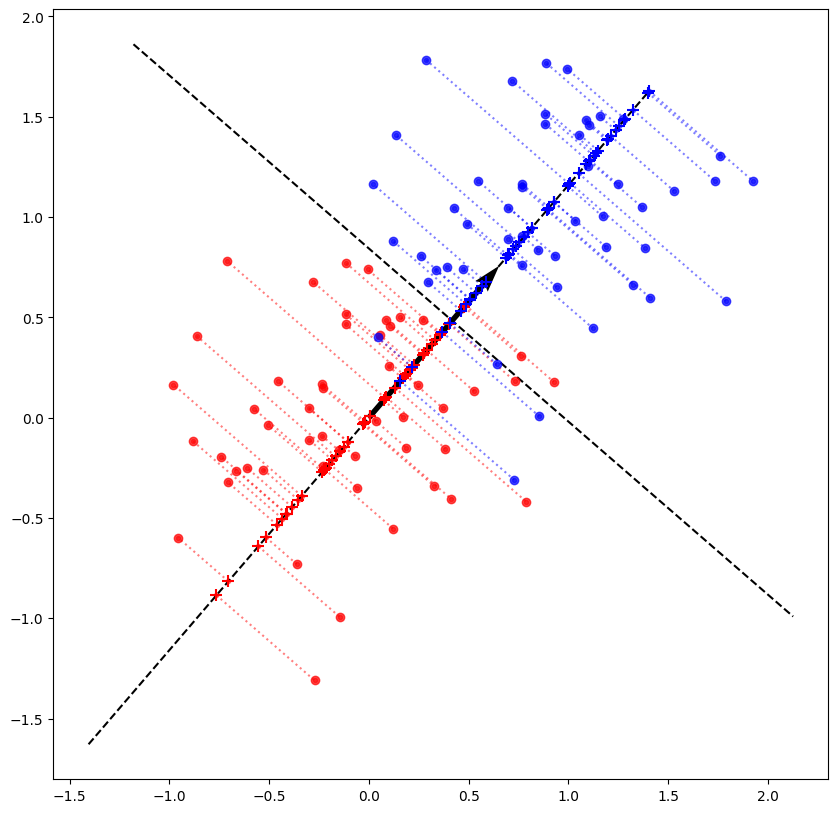

La imagen muestra que no cualquier dirección de proyección separa igualmente bien las clases. LDA busca las direcciones que conservan información relevante para discriminar las etiquetas.

##### Supuestos teóricos de LDA

En su formulación clásica, LDA supone que las variables discriminantes son cuantitativas y que las clases son mutuamente excluyentes. Además, se asume aproximadamente normalidad multivariante dentro de cada clase y matrices de covarianza similares entre clases. También debe evitarse dependencia lineal exacta entre variables.

Estos supuestos ayudan a justificar el modelo probabilístico que conduce a fronteras lineales. En la práctica, LDA puede seguir funcionando razonablemente cuando los supuestos se cumplen solo de manera aproximada.

#### 2. Carga y exploración del Wine dataset

**Consigna.** Cargue el dataset y responda:

1. ¿Cuántas muestras, variables predictoras y clases tiene?
2. ¿Las clases tienen exactamente la misma cantidad de muestras?

In [ ]:
# Código provisto
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print('X:', X.shape)
print('y:', y.shape)
print('Clases:', np.unique(y))
print('Cantidad por clase:')
print(pd.Series(y).value_counts().sort_index())

#### 3. División en entrenamiento y prueba

Para esta primera parte se reservará un conjunto de prueba que permanecerá fuera del entrenamiento. Utilice 

- `test_size=0.30`
- `random_state=42`
- `stratify=y`.

#### 4. Estandarización para la implementación manual

Para reproducir de manera estable los pasos matriciales de LDA y facilitar la comparación de magnitudes, se escalan las características.

> **Importante.** A diferencia de KNN y SVM, el LDA clásico no depende de distancias euclidianas entre atributos en la misma forma y, en teoría, una transformación lineal invertible de escala no debería cambiar esencialmente la regla discriminante. Aquí se escala principalmente por estabilidad numérica y para mantener un flujo de trabajo homogéneo.

In [ ]:
# Escale train y test



#### 5. Implementación guiada de LDA como reducción de dimensionalidad

En esta sección se provee el código. 

El objetivo es seguir el procedimiento y poder interpretar qué representa cada cantidad.

##### 5.1 Vectores de medias por clase

Para cada clase $i$ se calcula su vector de medias $\mathbf{m}_i$.

In [ ]:
# Código provisto
classes = np.unique(y_train)
mean_vectors = []

for label in classes:
    mean_vec = X_train_std[y_train == label].mean(axis=0)
    mean_vectors.append(mean_vec)
    print(f'Clase {label} - vector de medias:')
    print(mean_vec)
    print()

##### 5.2 Matriz de dispersión intra-clase $S_W$

La matriz de dispersión intra-clase acumula la variabilidad de las muestras alrededor de la media de su propia clase:

$$
S_W = \sum_{i=1}^{c}\sum_{\mathbf{x}\in D_i}
(\mathbf{x}-\mathbf{m}_i)(\mathbf{x}-\mathbf{m}_i)^T.
$$

In [ ]:
# Código provisto
d = X_train_std.shape[1]
S_W = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    X_class = X_train_std[y_train == label]
    centered = X_class - mean_vec
    S_W += centered.T @ centered

print('Dimensión de S_W:', S_W.shape)

##### 5.3 Matriz de dispersión entre-clases $S_B$

La dispersión entre clases se calcula respecto de la media global $\mathbf{m}$:

$$
S_B = \sum_{i=1}^{c} n_i(\mathbf{m}_i-\mathbf{m})(\mathbf{m}_i-\mathbf{m})^T.
$$

El factor $n_i$ pondera la contribución de cada clase según su cantidad de muestras.

In [ ]:
# Código provisto
mean_overall = X_train_std.mean(axis=0)
S_B = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    n_i = np.sum(y_train == label)
    mean_diff = (mean_vec - mean_overall).reshape(d, 1)
    S_B += n_i * (mean_diff @ mean_diff.T)

print('Dimensión de S_B:', S_B.shape)

##### 5.4 Problema de autovalores y matriz de proyección

La formulación clásica conduce a estudiar las direcciones principales asociadas a:

$$
S_W^{-1}S_B.
$$

En el código se utiliza la pseudoinversa de $S_W$ en lugar de formar explícitamente una inversa numérica. 

Luego se ordenan los autovalores de mayor a menor y se seleccionan los dos autovectores principales.

In [ ]:
# Código provisto
matrix_lda = np.linalg.pinv(S_W) @ S_B
eigen_vals, eigen_vecs = np.linalg.eig(matrix_lda)

eigen_pairs = [
    (eigen_vals[i].real, eigen_vecs[:, i].real)
    for i in range(len(eigen_vals))
]
eigen_pairs = sorted(eigen_pairs, key=lambda pair: pair[0], reverse=True)

print('Mayores autovalores:')
for value, _ in eigen_pairs:
    print(f'{value:.6f}')

W = np.column_stack([eigen_pairs[0][1], eigen_pairs[1][1]])
print('\nDimensión de W:', W.shape)

##### 5.5 Proyección al espacio LDA

La transformación se obtiene mediante:

$$
X_{LDA}=XW.
$$

In [ ]:
# Código provisto
X_train_lda_manual = X_train_std @ W
X_test_lda_manual = X_test_std @ W

plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']
for idx, label in enumerate(classes):
    plt.scatter(
        X_train_lda_manual[y_train == label, 0],
        X_train_lda_manual[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )
plt.xlabel('LD1 manual')
plt.ylabel('LD2 manual')
plt.title('Wine - proyección LDA implementada paso a paso')
plt.legend()
plt.show()

**Preguntas de análisis**

1. ¿Qué dimensión tiene $W$? ¿Por qué? 
2. ¿Por qué aparecen solamente dos autovalores importantes aunque el dataset tenga 13 variables?¿cuántas dimensiones tiene el espacio discriminante?
3. ¿Qué significa geométricamente que las clases se separen mejor después de la proyección?

#### 6. LDA con scikit-learn como transformación supervisada

Utilice `LinearDiscriminantAnalysis(n_components=2)` y compare la representación obtenida con la implementación manual.

**Investigue:**

1. ¿La proyección de scikit-learn debe ser idéntica punto por punto a la implementación manual?
2. ¿Qué significan los valores de `explained_variance_ratio_` del LDA de scikit-learn?
3. ¿Por qué el signo de un eje discriminante puede aparecer invertido sin que exista un error?

#### 7. LDA como clasificador

Hasta aquí LDA se utilizó como transformación. Ahora úselo directamente como clasificador y evalúe su desempeño sobre el conjunto de prueba reservado. Calcule también la matriz de confusión.

**Preguntas de análisis**

1. ¿Cuántas muestras fueron clasificadas incorrectamente?
2. ¿Qué diferencia conceptual existe entre usar LDA con `transform()` y usarlo con `predict()`?
3. ¿La frontera de decisión de LDA es lineal o no lineal?

#### 8. Validación cruzada:

Una única división entrenamiento/prueba puede producir un resultado dependiente de qué muestras quedaron en cada subconjunto. La **validación cruzada de $k$ particiones** repite el proceso $k$ veces: cada partición actúa una vez como validación y las restantes como entrenamiento.

En esta sección se utilizarán 5 particiones. El conjunto de prueba reservado anteriormente **no participa** de esta validación cruzada.

**Consigna.** 

Calcule los cinco accuracies de validación cruzada de LDA sobre `X_train, y_train` usando `cross_val_score` de scikit-learn y reporte media y desviación estándar.

**Preguntas de análisis**

1. ¿Por qué aparecen cinco valores de accuracy?
2. ¿Qué representa la media de esos valores?
3. ¿Qué información aporta la desviación estándar?
4. ¿Validación cruzada y búsqueda de hiperparámetros son lo mismo?

#### 9. Efecto del escalado en LDA
Compare mediante validación cruzada LDA con y sin `StandardScaler`.

## Parte B. Máquinas de Soporte Vectorial (SVM)

Una SVM lineal busca un hiperplano de separación:

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

que separe las clases maximizando el **margen**. Los puntos más próximos a la frontera son los **vectores de soporte** y determinan la solución.

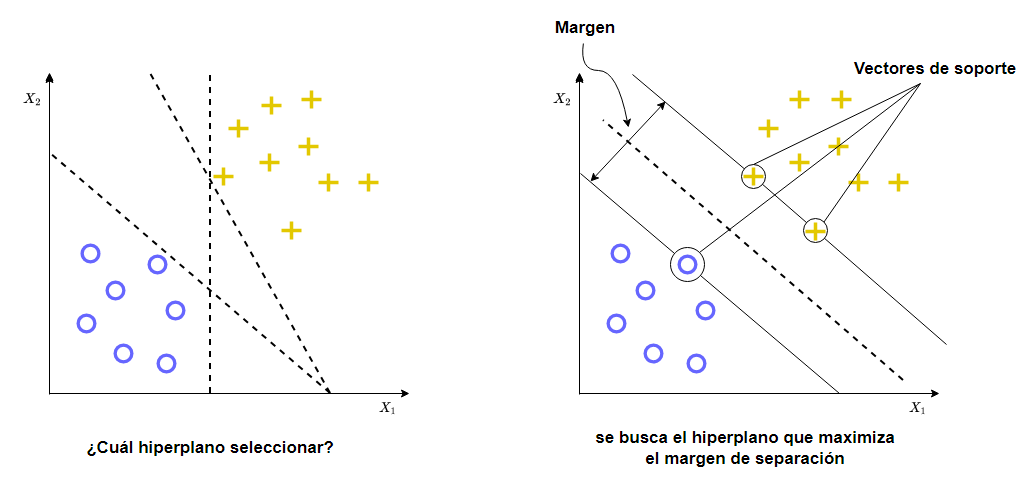

#### 10. Margen blando y parámetro $C$

Cuando los datos contienen ruido, solapamiento e instancias atípicas, exigir separación perfecta puede producir una frontera poco generalizable. La SVM de margen blando introduce variables de holgura $\xi_i$ y resuelve conceptualmente un compromiso del tipo:

$$
\min_{\mathbf{w},b,\xi}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i.
$$

El hiperparámetro $C$ controla cuánto se penalizan las violaciones del margen:

- **$C$ grande:** penaliza fuertemente los errores; la frontera intenta ajustarse más a las muestras de entrenamiento;
- **$C$ pequeño:** tolera más violaciones y favorece un margen más amplio.

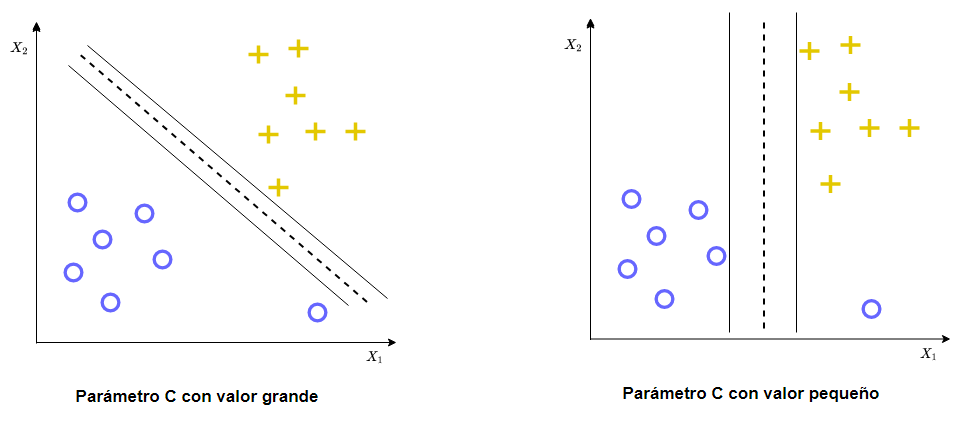

> **Escalado en SVM.** SVM es sensible a la escala de los atributos porque tanto el margen como, en kernels como RBF, las distancias entre muestras dependen de la geometría del espacio. Por eso se utilizará `StandardScaler` dentro de un `Pipeline`.

#### 11. Dataset 1: efecto de $C$ y de una observación atípica

El primer dataset es bidimensional y aproximadamente linealmente separable, pero contiene una observación atípica.

**Consigna.** 

Entrene SVM lineales con $C\in\{0.01,1,100\}$ y analice cómo cambia la frontera, el número de vectores de soporte y el ajuste al dato atípico.

Use la función `plot_decision_boundary` provista al inicio de la notebook

In [ ]:
# Código provisto
mat1 = sio.loadmat(DATA_DIR / 'data1.mat')
X_svm1 = mat1['X']
y_svm1 = mat1['y'].ravel()

print('Dimensiones:', X_svm1.shape)
print('Clases:', np.unique(y_svm1))
plot_labeled_points(X_svm1, y_svm1, 'Dataset 1 - SVM lineal')

**Preguntas de análisis**

1. ¿Qué ocurre con el margen cuando $C$ disminuye?
2. ¿Qué ocurre con el ajuste al outlier cuando $C$ aumenta?
3. ¿Qué riesgo aparece con un $C$ excesivamente grande?
4. ¿Por qué no debería elegirse $C$ solamente observando el accuracy de entrenamiento?

#### 12. Dataset 2: SVM con kernel RBF y efecto de $\gamma$

Cuando las clases no son separables mediante un hiperplano en el espacio original, una SVM puede utilizar un **kernel**. El kernel RBF o Gaussiano se define como:

$$
K(\mathbf{x},\mathbf{z})=\exp\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right).
$$

El parámetro $\gamma$ controla el alcance de influencia de cada muestra:

- $\gamma$ pequeño: influencia más amplia y frontera más suave;
- $\gamma$ grande: influencia más local y frontera potencialmente más compleja.

**Consigna.** 

Mantenga $C=1$ y compare $\gamma\in\{0.01,1,100\}$.

Use la función `plot_decision_boundary` provista al inicio de la notebook

In [ ]:
# Código provisto: carga y visualización
mat2 = sio.loadmat(DATA_DIR / 'data2.mat')
X_svm2 = mat2['X']
y_svm2 = mat2['y'].ravel()

print('Dimensiones:', X_svm2.shape)
print('Cantidad por clase:', np.bincount(y_svm2.astype(int)))
plot_labeled_points(X_svm2, y_svm2, 'Dataset 2 - problema no lineal')

**Preguntas de análisis**

1. ¿Qué comportamiento se observa con un $\gamma$ demasiado pequeño?
2. ¿Qué comportamiento se observa con un $\gamma$ demasiado grande?
3. ¿La configuración que obtiene el mayor accuracy de entrenamiento puede considerarse automáticamente la mejor? Justifique.

## Parte C. Selección de hiperparámetros y evaluación final

#### 13. Entrenamiento, validación y prueba

Cuando se entrenan varios modelos o se prueban diferentes hiperparámetros, el conjunto de prueba debe mantenerse completamente separado hasta el final.

Se distinguen tres funciones para los datos:

- **Train:** ajustar los parámetros del modelo.
- **Validation:** comparar configuraciones e hiperparámetros.
- **Test:** realizar una evaluación final del procedimiento elegido.

Si los datos disponibles no permiten reservar una gran fracción para validación, puede utilizarse **validación cruzada** sobre los datos de desarrollo. Aun utilizando validación cruzada, conviene conservar un conjunto de prueba independiente para la evaluación final.

En esta sección se utilizará `data3_train_val_test.mat`, preparado con conjuntos explícitos de entrenamiento, validación y prueba.

In [ ]:
# Código provisto
mat3 = sio.loadmat(DATA_DIR / 'data3_train_val_test.mat')

X_train_3 = mat3['X_train']
y_train_3 = mat3['y_train'].ravel()
X_val_3 = mat3['X_val']
y_val_3 = mat3['y_val'].ravel()
X_test_3 = mat3['X_test']
y_test_3 = mat3['y_test'].ravel()

print('Train:', X_train_3.shape, np.bincount(y_train_3.astype(int)))
print('Validation:', X_val_3.shape, np.bincount(y_val_3.astype(int)))
print('Test:', X_test_3.shape, np.bincount(y_test_3.astype(int)))

plt.figure(figsize=(7, 5))
for label in np.unique(y_train_3):
    plt.scatter(
        X_train_3[y_train_3 == label, 0],
        X_train_3[y_train_3 == label, 1],
        alpha=0.65,
        label=f'Train - clase {label}',
    )
plt.scatter(X_val_3[:, 0], X_val_3[:, 1], marker='x', alpha=0.55, label='Validation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset 3 - train y validation')
plt.legend()
plt.show()

#### 14. Selección manual con un único conjunto de validación

Primero se imitará un procedimiento clásico de selección hold-out:

1. entrenar cada combinación de $C$ y $\gamma$ usando **solo train**;
2. medir su accuracy en **validation**;
3. ordenar las configuraciones de mayor a menor desempeño.

Use:

```python
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]
```

**Importante:** el escalado debe estar dentro de un `Pipeline`, de modo que cada modelo ajuste el escalador solo con sus datos de entrenamiento.

In [ ]:

valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]



**Preguntas de análisis**

1. ¿Hay una única combinación ganadora o aparecen empates?
2. Si varias configuraciones obtienen el mismo accuracy de validación, ¿qué problema aparece al elegir una?
3. ¿Podemos utilizar el conjunto de test para desempatar?
4. ¿Qué limitación tiene basar toda la decisión en un único conjunto de validación de 100 muestras?

#### 15. Validación cruzada para seleccionar hiperparámetros

Ahora se combinarán `train` y `validation` en un conjunto de **train_val**. El conjunto de test seguirá completamente aislado.

Para cada combinación de $C$ y $\gamma$ se calculará el accuracy medio de una validación cruzada de 5 particiones usando `cross_val_score`.

Esto permite que diferentes subconjuntos de `train_val` actúen como validación, reduciendo la dependencia respecto de una única partición.

In [ ]:
# Código provisto
X_train_val_3 = np.vstack([X_train_3, X_val_3])
y_train_val_3 = np.concatenate([y_train_3, y_val_3])

print('Train+Val:', X_train_val_3.shape)
print('Test reservado:', X_test_3.shape)

**Preguntas de análisis**

1. ¿La mejor combinación obtenida con validación cruzada coincide necesariamente con alguna de las mejores del hold-out validation?
2. ¿Por qué el mejor accuracy medio de CV puede ser menor que el obtenido con hold-out?
3. ¿Qué información adicional aporta `cv_std`?

#### 16. Automatización con `GridSearchCV`

`GridSearchCV` automatiza el procedimiento anterior:

- genera todas las combinaciones del diccionario `param_grid`
- evalúa cada combinación mediante validación cruzada
- selecciona la configuración con mejor score medio
- vuelve a ajustar el mejor pipeline utilizando todos los datos del conjunto train_val cuando `refit=True`.

**Consigna.** Repita la búsqueda anterior con `GridSearchCV` y compare los resultados con la búsqueda manual.

**¿Llega al mismo resultado?**

In [ ]:
param_grid = {
    'svc__C': valores_C,
    'svc__gamma': valores_gamma,
}



#### 17. Evaluación final sobre test

Hasta este punto, el conjunto `X_test_3, y_test_3` no se utilizó para elegir hiperparámetros. Recién ahora se empleará para estimar el desempeño final del mejor modelo seleccionado.

**Consigna.** Evalúe `grid_search.best_estimator_` sobre test, muestre la matriz de confusión y grafique la frontera de decisión.

Use la función `plot_decision_boundary` provista al inicio de la notebook

**Preguntas de análisis**

1. ¿Por qué el test debe utilizarse recién después de finalizar la selección de hiperparámetros?
2. ¿Qué ocurriría si, al ver el resultado de test, modificáramos nuevamente $C$ o $\gamma$ para mejorarlo?

## Parte D. Comparar LDA y SVM sobre el mismo problema

Volvamos al Wine dataset. Utilice la misma partición que usó al inicio (train + test).

El objetivo es comparar modelos utilizando **la misma estrategia de evaluación**, evitando comparar scores obtenidos bajo procedimientos distintos.

Se considerarán tres clasificadores:

- LDA
- SVM lineal
- SVM con kernel RBF.

LDA se evaluará por validación cruzada. Para las SVM, los hiperparámetros se seleccionarán con `GridSearchCV` sobre el mismo conjunto de entrenamiento. El conjunto de prueba de Wine seguirá reservado hasta seleccionar el mejor candidato según CV.

#### 18. Comparación de clasificadores

**Consigna.** Sobre `X_train, y_train`:

1. estime el desempeño de LDA con `cross_val_score(cv=5)`;
2. seleccione $C$ para SVM lineal mediante `GridSearchCV`;
3. seleccione $C$ y $\gamma$ para SVM RBF mediante `GridSearchCV`;
4. compare los mejores scores medios de validación cruzada.

**¿Qué modelo obtiene el mejor score medio de CV en esta ejecución?**

#### 19. Evaluación del modelo seleccionado en Wine

Seleccione el candidato con mejor score de validación cruzada y evalúelo **una sola vez** sobre el test reservado al comienzo.

**Comente el resultado**

#### 20. LDA como transformación antes de otro clasificador

LDA también puede colocarse dentro de un `Pipeline` antes de otro clasificador. Esto permite estudiar una secuencia del tipo:

$$
X \rightarrow \text{StandardScaler} \rightarrow \text{LDA} \rightarrow \text{SVM}.
$$

La transformación LDA es **supervisada**, porque utiliza las etiquetas $y$. Por eso, si se evalúa mediante validación cruzada, LDA debe ajustarse **dentro de cada fold**. Ajustar LDA sobre todo el dataset y luego hacer CV sobre la representación transformada produciría fuga de información.

**Consigna** 

Evalúe el pipeline `Scaler → LDA(n_components=2) → SVM lineal` con validación cruzada.

Compare con los resultados de los modelos en 19 y comente el resultado